# S2_Sentinel_JDSSS_QC.ipynb
This notebook investigates the Sentinel-1 QC algorithm over the JDSSS site.

For additional details see ../paper_new/fig_2_CUES_SM_S1_QC.ipynb


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import importlib
import sys
from pathlib import Path
import xarray as xr
import pandas as pd


# gets rid of a lot of annoying warnings, we know there are NaNs (might want to remove this to double check)
import warnings
warnings.filterwarnings("ignore")


In [2]:
sys.path.insert(1, '../scripts/')

In [3]:
import metadata as metadata
import load_data as load_data
import plotting as plotting
import melt_phases as melt_phases


In [4]:
import importlib
importlib.reload(metadata)
importlib.reload(load_data)
importlib.reload(plotting)
importlib.reload(melt_phases)


<module 'melt_phases' from '/glade/u/home/rossamower/school/uw/cues_git/cues_sentinel_snowmodel/python/supporting_information/../scripts/melt_phases.py'>

# Load Data

## Metadata

### point locations

#### CUES

In [5]:
importlib.reload(metadata)
# load config
cues_cfg = metadata.load_yaml(Path(f"../../configs/CUES.yaml"))
# load point geometry
_,_,cues_x,cues_y,_ = metadata.get_point_geography(cues_cfg,'cues')
# load snowmodel filepath
sm_cues_OBS_swe_fpath = metadata.get_cuesOBS_fpath(cues_cfg,'swe')


### polygon geometries

In [6]:
importlib.reload(metadata)
# cues
cues_geog_fpath,aso_crs = metadata.get_shapefile_fpath(cues_cfg,"shapefile_fpath","zoom_2")
# read shapefile
cues_geog_gdf = gpd.read_file(cues_geog_fpath)
cues_proj_gdf = cues_geog_gdf.to_crs(f'EPSG:{aso_crs}')


## time series

### SWE

#### CUES

In [7]:
importlib.reload(load_data)
cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df = load_data.load_cues_OBS_SWE(sm_cues_OBS_swe_fpath)
cues_obs_swe_all_df = pd.concat([cues_obs_swe_qa_df,cues_obs_swe_NO_qa_df])
cues_obs_swe_all_df.drop(columns = ['water_year'],inplace = True)
cues_obs_swe_all_df['DateTime'] = pd.to_datetime(cues_obs_swe_all_df['DateTime'])
cues_obs_swe_all_df.rename(columns = {'DateTime':'time',
                                      'SWE':'swed'},inplace = True)
cues_swe_ds = cues_obs_swe_all_df.set_index('time').to_xarray()
cues_swe_m_ds = (cues_swe_ds['swed'] / 1000).to_dataset(name = 'swed')


## Point Data

### TAIR

In [8]:
ds_temp = xr.open_dataset('../../data/cues/cues/cues_2015_2025.nc')[['air_temperature','air_temperature_data_flag']]
ds_temp_day = ds_temp.resample(datetime='1D').mean()

### S-1 Backscatter

In [9]:
importlib.reload(load_data)
sentinel_cues_100m_2017 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2018 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2019 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

sentinel_cues_100m_2020 = load_data.load_sentinel_backscatter('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/bscatter/',
                  cues_proj_gdf,
                  wy = None,
                  )

idy_cues,idx_cues = load_data.sm_intersect_rectilinear(sentinel_cues_100m_2017.y.values,sentinel_cues_100m_2017.x.values,cues_y,cues_x)

### S-1 Reference Scene

In [10]:
importlib.reload(load_data)                                                                   
sentinel_cues_reference_2017 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                                                                  )


sentinel_cues_reference_2018 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

sentinel_cues_reference_2019 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/melt_thresh/reference/',
                                                                   aso_crs,
                                                                  cues_proj_gdf,
                  )

sentinel_cues_reference_2020 = load_data.load_sentinel_reference('/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/melt_thresh/reference/',
                                                                   aso_crs,
                                                                   cues_proj_gdf,
                  )

## Investigate Missing Reference Period 2017

In [11]:
import importlib
import sys

# Force complete reimport of melt_phases module
for mod in list(sys.modules.keys()):
    if 'melt_phases' in mod:
        del sys.modules[mod]

import melt_phases
importlib.reload(melt_phases)

path_2017_prev_yr = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/melt_thresh/data/datasets/'
path_2017_curr_yr = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2017/melt_thresh_following_ref/data/datasets/' # using current year because previous year was NaN
path_2019_prev_yr = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2019/melt_thresh/data/datasets/'
path_2019_curr_yr = f'{metadata.get_sentinel_fpath(cues_cfg, "100m")}2019/melt_thresh_following_ref/data/datasets/' # using current year because previous year was NaN


    
# path_2017 = '/glade/derecho/scratch/rossamower/snow/snowmodel/school/uw/cues/data/sentinel/cues/100_m/2017/melt_thresh/data/datasets'
cfg_marin = melt_phases.MarinS1VVCfg(
    tau_db=-2.0,
    min_stability_days=28,
    max_group_spread_days=28,
    max_am_pm_mismatch_days=28,
)

cfg_w = melt_phases.WeightedMinimaCfg(
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
    cfg_marin=cfg_marin,
)

ts_2017_prev_yr = melt_phases.build_point_timeseries_all_orbits_from_files(
    path_2017_prev_yr, cues_y, cues_x,
    orbits=(64, 137, 144),
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
)

ts_2017_curr_yr = melt_phases.build_point_timeseries_all_orbits_from_files(
    path_2017_curr_yr, cues_y, cues_x,
    orbits=(64, 137, 144),
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
)

ts_2019_prev_yr = melt_phases.build_point_timeseries_all_orbits_from_files(
    path_2019_prev_yr, cues_y, cues_x,
    orbits=(64, 137, 144),
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
)

ts_2019_curr_yr = melt_phases.build_point_timeseries_all_orbits_from_files(
    path_2019_curr_yr, cues_y, cues_x,
    orbits=(64, 137, 144),
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
)

weighted_phase_2017_prev_yr = melt_phases.run_s1_rc_minima_year(path_2017_prev_yr, cues_y, cues_x, 2017, cfg_w)
weighted_phase_2017_curr_yr = melt_phases.run_s1_rc_minima_year(path_2017_curr_yr, cues_y, cues_x, 2017, cfg_w)
weighted_phase_2019_prev_yr = melt_phases.run_s1_rc_minima_year(path_2019_prev_yr, cues_y, cues_x, 2019, cfg_w)
weighted_phase_2019_curr_yr = melt_phases.run_s1_rc_minima_year(path_2019_curr_yr, cues_y, cues_x, 2019, cfg_w)

### Investigate Rc Time Series Using Reference Image Generated From ***PREVIOUS*** Year (ie 15 July 2016 - 1 Sept 2016)

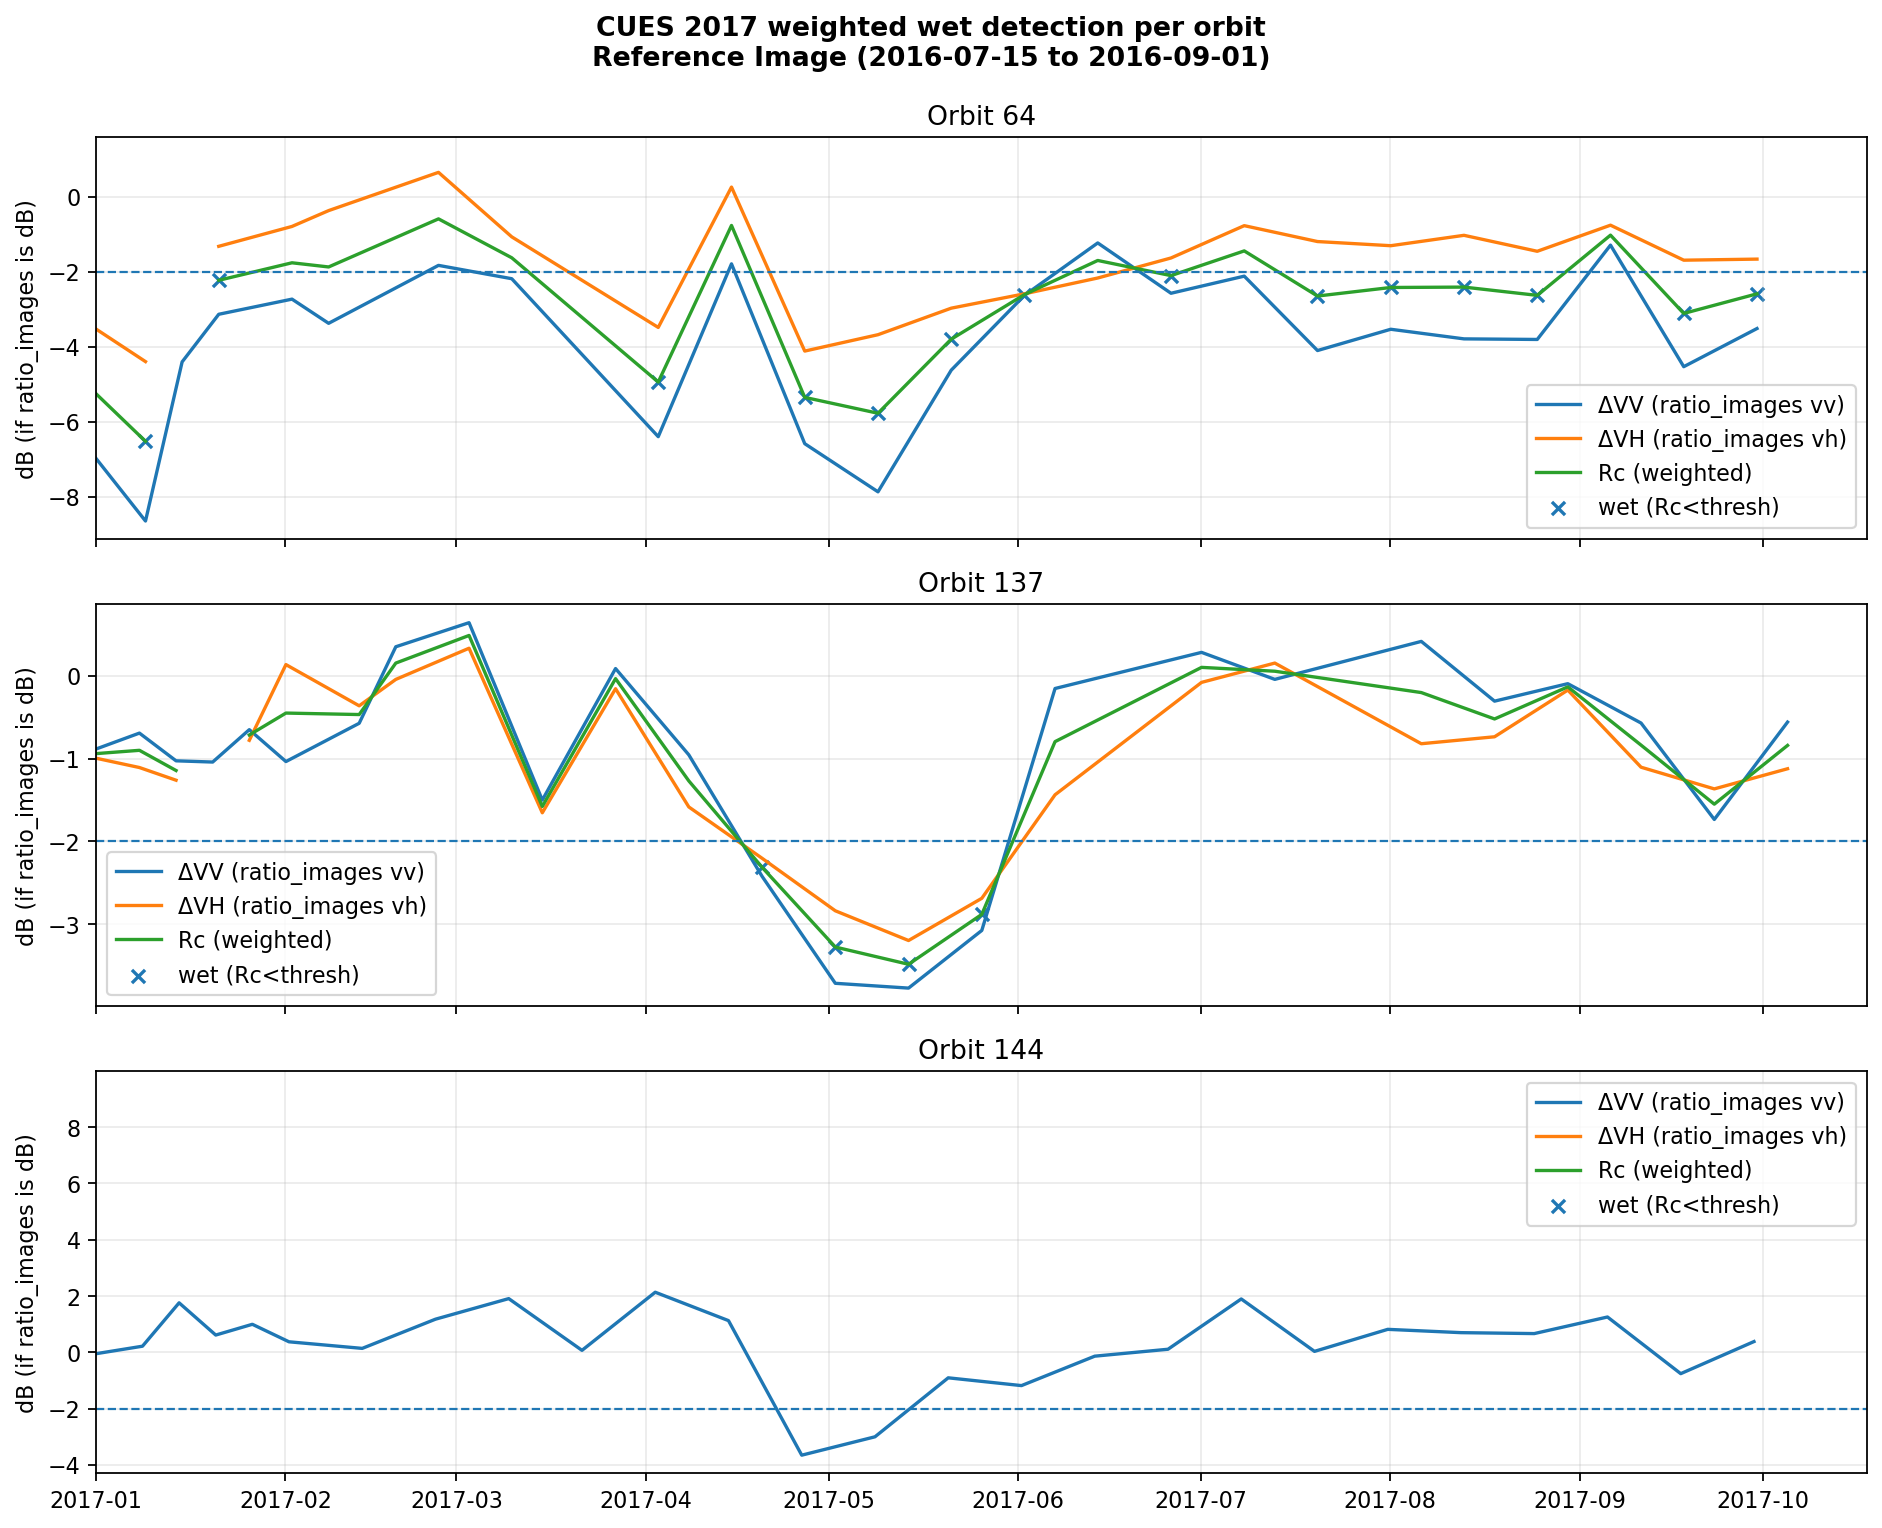

In [12]:
importlib.reload(plotting)


plotting.plot_orbit_timeseries(ts_2017_prev_yr, 
                               wet_thresh_db=-2.0, 
                               title="CUES 2017 weighted wet detection per orbit\nReference Image (2016-07-15 to 2016-09-01)",
                               xmin_ = np.datetime64('2017-01-01'))

### Investigate Rc Time Series Using Reference Image Generated From ***CURRENT*** Year (ie 15 July 2017 - 1 Sept 2017)

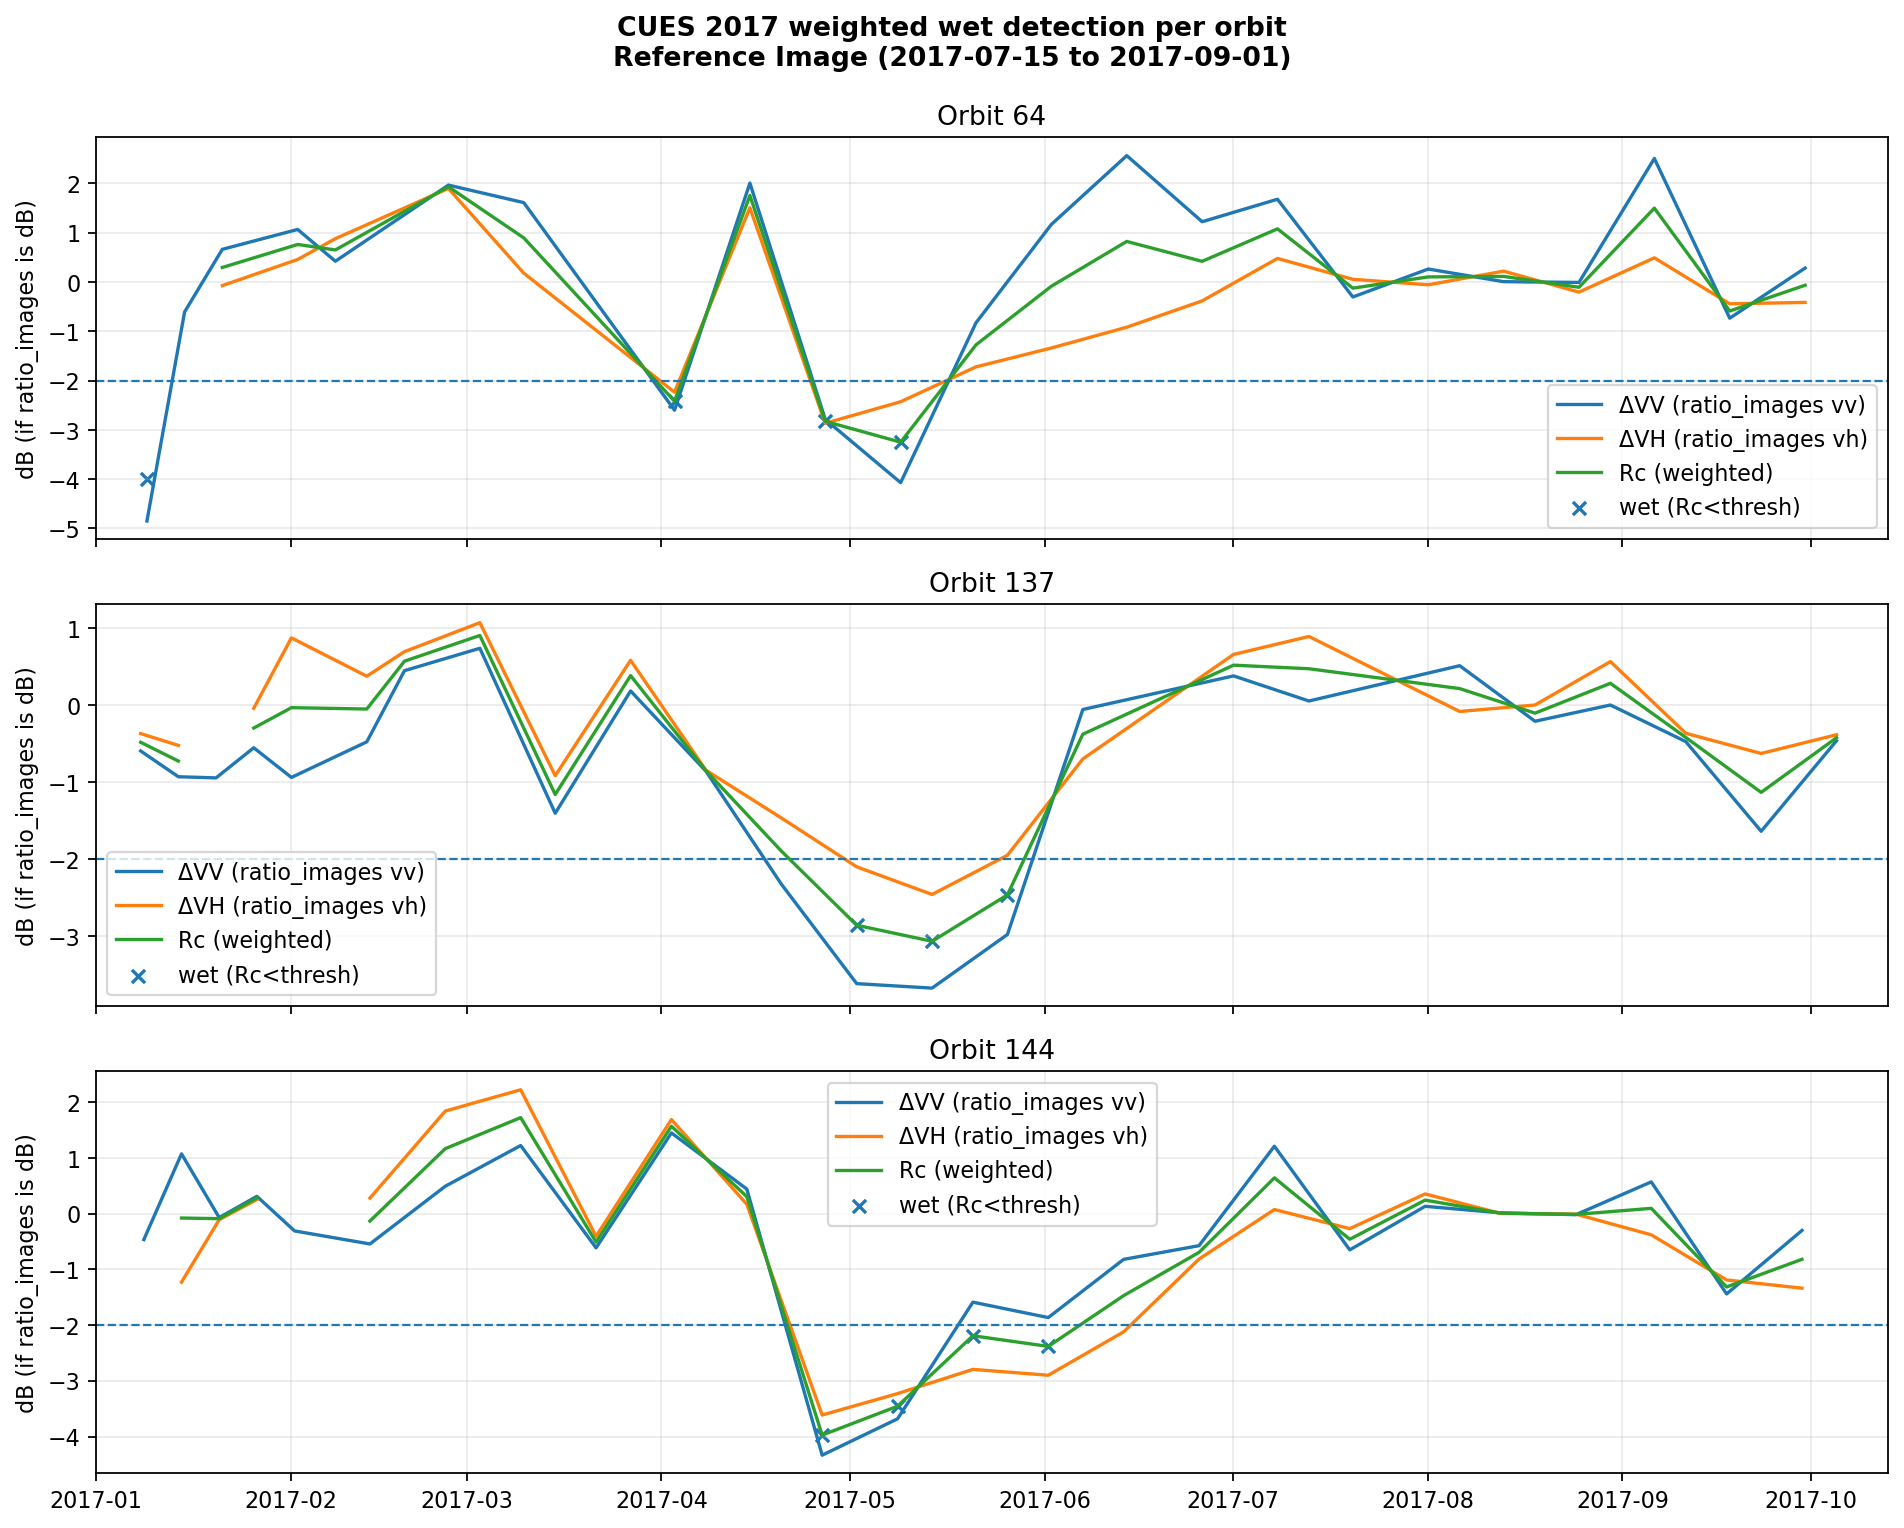

In [13]:
import plotting as plotting


plotting.plot_orbit_timeseries(ts_2017_curr_yr, 
                               wet_thresh_db=-2.0, 
                               title="CUES 2017 weighted wet detection per orbit\nReference Image (2017-07-15 to 2017-09-01)",
                              xmin_ = np.datetime64('2017-01-01'))

### Plot comparison of S1-Rc time series in 2017 and melt phases in 2019

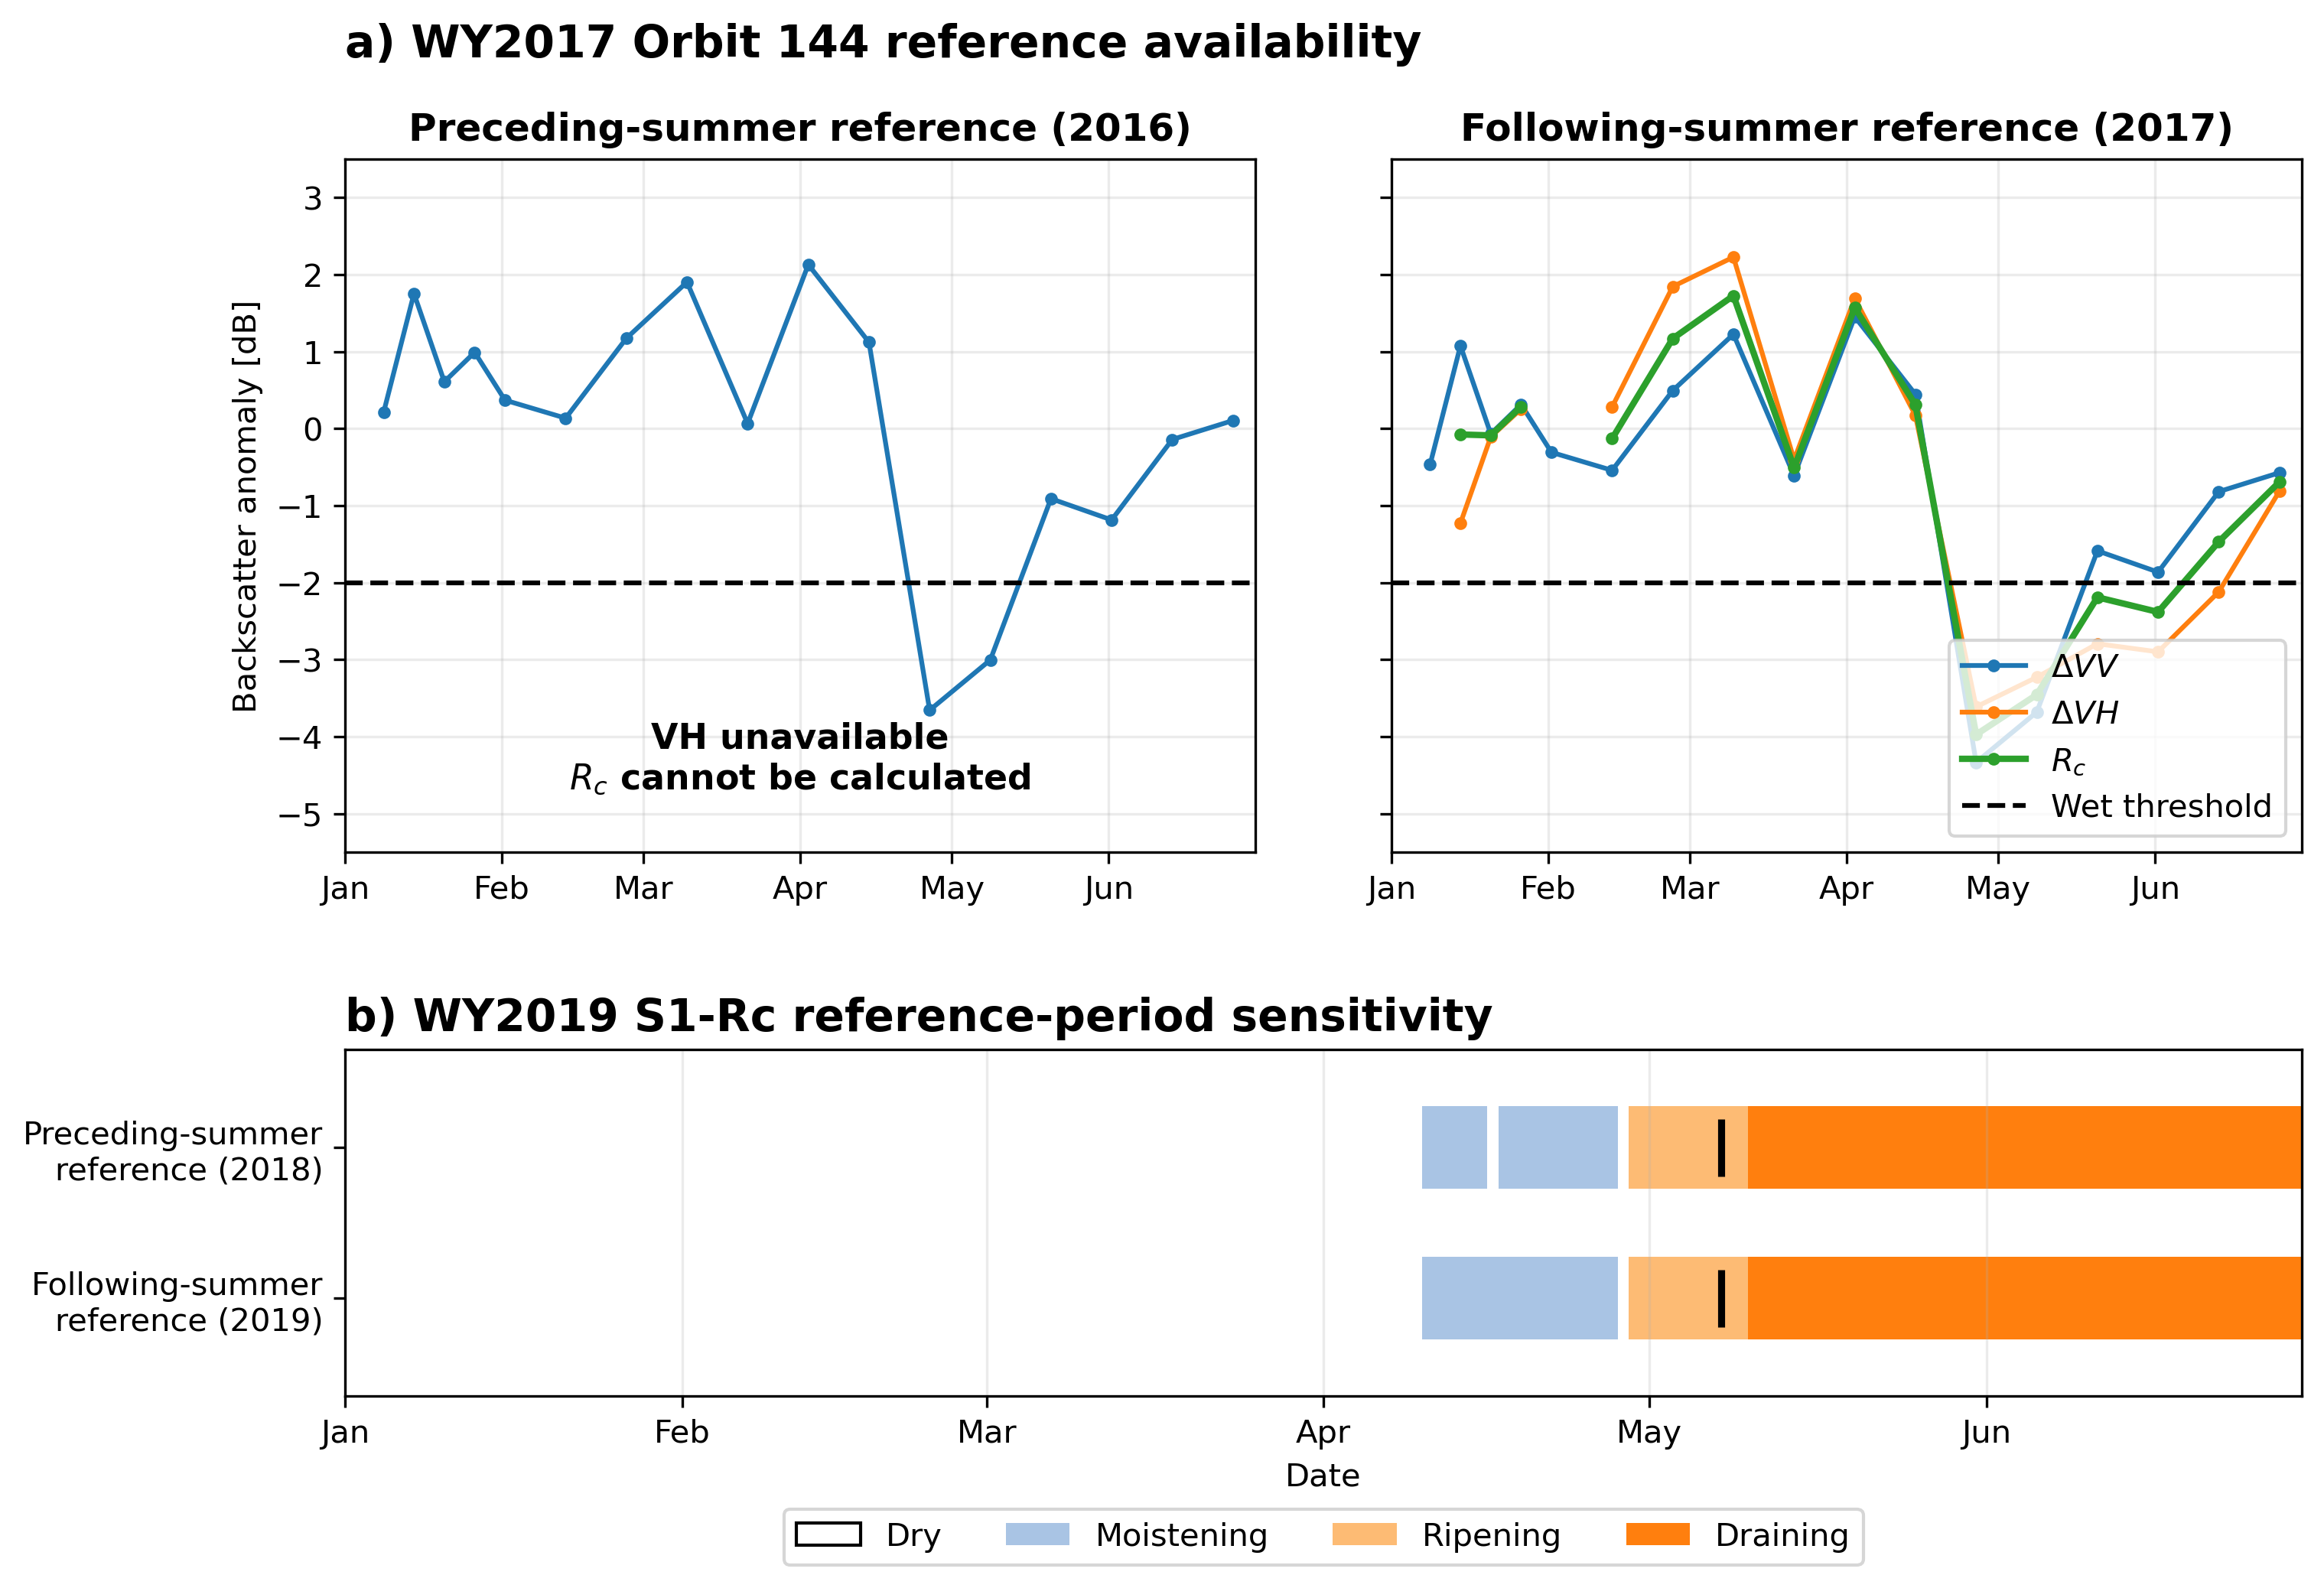

In [14]:
from matplotlib.patches import Patch
import matplotlib.dates as mdates


# ============================================================
# Settings
# ============================================================

wet_thresh = -2.0

# Use the same phase colors as the manuscript figures
phase_colors = {
    "dry": "white",

    "moist": "#a9c4e4",
    "moistening": "#a9c4e4",

    "ripe": "#fdbb74",
    "ripening": "#fdbb74",

    "output": "#ff7f0e",
    "drain": "#ff7f0e",
    "draining": "#ff7f0e",
}

# Analysis windows
start_2017 = pd.Timestamp("2017-01-01")
end_2017   = pd.Timestamp("2017-06-30")

start_2019 = pd.Timestamp("2019-01-01")
end_2019   = pd.Timestamp("2019-06-30")


# ============================================================
# Figure
# ============================================================

fig = plt.figure(figsize=(11, 7),dpi = 300)

gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[2.0, 1.0],
    hspace=0.38,
    wspace=0.15,
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])


# ============================================================
# A) WY2017 reference availability
# ============================================================

orbit = 144

plotting.plot_rc_timeseries(
    ax1,
    ts_2017_prev_yr[orbit],
    start_2017,
    end_2017,
    "Preceding-summer reference (2016)",
    show_missing_annotation=True,
)

plotting.plot_rc_timeseries(
    ax2,
    ts_2017_curr_yr[orbit],
    start_2017,
    end_2017,
    "Following-summer reference (2017)",
    show_missing_annotation=False,
)

ax1.set_ylabel("Backscatter anomaly [dB]")

# Make top-panel y axes identical
vals = []

for ds in [
    ts_2017_prev_yr[orbit],
    ts_2017_curr_yr[orbit],
]:
    ds_tmp = ds.sel(Time=slice(start_2017, end_2017))

    for var in ["dvv", "dvh", "Rc"]:
        v = ds_tmp[var].values
        vals.extend(v[np.isfinite(v)])

vals = np.asarray(vals)

if len(vals) > 0:
    ymin = np.floor(vals.min()) - 0.5
    ymax = np.ceil(vals.max()) + 0.5

    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)

ax2.set_yticklabels([])

# One legend for panel A
handles, labels = ax2.get_legend_handles_labels()

ax2.legend(
    handles,
    labels,
    loc="lower right",
    frameon=True,
)

fig.text(
    ax3.get_position().x0,
    0.965,
    "a) WY2017 Orbit 144 reference availability",
    fontsize=14,
    fontweight="bold",
    va="top",
)


# ============================================================
# B) WY2019 sensitivity test
# ============================================================

plotting.plot_phase_strip(
    ax3,
    weighted_phase_2019_prev_yr,
    y=1,
    label="Preceding-summer reference",
    start=start_2019,
    end=end_2019,
)

plotting.plot_phase_strip(
    ax3,
    weighted_phase_2019_curr_yr,
    y=0,
    label="Following-summer reference",
    start=start_2019,
    end=end_2019,
)

ax3.set_xlim(start_2019, end_2019)

ax3.set_yticks([1, 0])
ax3.set_yticklabels([
    "Preceding-summer\nreference (2018)",
    "Following-summer\nreference (2019)",
])

ax3.set_ylim(-0.65, 1.65)

ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

ax3.set_xlabel("Date")

ax3.grid(axis="x", alpha=0.25)

ax3.set_title(
    "b) WY2019 S1-Rc reference-period sensitivity",
    fontsize=14,
    loc="left",
    fontweight="bold",
)


# ============================================================
# Phase legend
# ============================================================

phase_handles = [
    Patch(
        facecolor=phase_colors["dry"],
        edgecolor="black",
        label="Dry",
    ),
    Patch(
        facecolor=phase_colors["moistening"],
        label="Moistening",
    ),
    Patch(
        facecolor=phase_colors["ripening"],
        label="Ripening",
    ),
    Patch(
        facecolor=phase_colors["draining"],
        label="Draining",
    ),
]

ax3.legend(
    handles=phase_handles,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.28),
    frameon=True,
)

plt.savefig('./pngs/S1_JDSSS_S1_Rc_Reference_Comparison',dpi = 300)
plt.show()

## Melt Phases

### S-1

#### VV (Nagler 1996)

In [15]:
importlib.reload(melt_phases)

cfg = melt_phases.MarinS1VVCfg(min_stability_days=28,
                              max_group_spread_days=28,
                              max_am_pm_mismatch_days=28
                              )

vv_out_2017 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2017, sentinel_cues_reference_2017, idy_cues, idx_cues, 2017, cfg)
vv_out_2018 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2018, sentinel_cues_reference_2018, idy_cues, idx_cues, 2018, cfg)
vv_out_2019 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2019, sentinel_cues_reference_2019, idy_cues, idx_cues, 2019, cfg)
vv_out_2020 = melt_phases.run_s1_vv_year(sentinel_cues_100m_2020, sentinel_cues_reference_2020, idy_cues, idx_cues, 2020, cfg)

print(vv_out_2017["output_start"], vv_out_2017["qc_ok"], vv_out_2017["qc_reason"])
print(vv_out_2018["output_start"], vv_out_2018["qc_ok"], vv_out_2018["qc_reason"])
print(vv_out_2019["output_start"], vv_out_2019["qc_ok"], vv_out_2019["qc_reason"])
print(vv_out_2020["output_start"], vv_out_2020["qc_ok"], vv_out_2020["qc_reason"])

2017-05-05 07:59:03.969113600 True OK
NaT False NO_GOOD_MORNING_ORBIT
NaT False AM_PM_MINIMA_MISMATCH
NaT False AM_PM_MINIMA_MISMATCH


#### Weighted Combination (Nagler 2016)

In [16]:
import importlib
import sys

# Force complete reimport of melt_phases module
for mod in list(sys.modules.keys()):
    if 'melt_phases' in mod:
        del sys.modules[mod]

import melt_phases
importlib.reload(melt_phases)
importlib.reload(plotting)

path_2017 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2017/melt_thresh_following_ref/data/datasets/"
path_2018 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2018/melt_thresh/data/datasets/"
path_2019 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2019/melt_thresh/data/datasets/"
path_2020 = "/glade/u/home/rossamower/rmower/pixel/sentinel/cues/100_m/2020/melt_thresh/data/datasets/"
cfg_marin = melt_phases.MarinS1VVCfg(
    tau_db=-2.0,
    min_stability_days=28,
    max_group_spread_days=28,
    max_am_pm_mismatch_days=28,
)

cfg_w = melt_phases.WeightedMinimaCfg(
    k=0.5, theta1=20, theta2=45,
    wet_thresh_db=-2.0,
    cfg_marin=cfg_marin,
)

weighted_out_2017 = melt_phases.run_s1_rc_minima_year(path_2017, cues_y, cues_x, 2017, cfg_w)
weighted_out_2018 = melt_phases.run_s1_rc_minima_year(path_2018, cues_y, cues_x, 2018, cfg_w)
weighted_out_2019 = melt_phases.run_s1_rc_minima_year(path_2019, cues_y, cues_x, 2019, cfg_w)
weighted_out_2020 = melt_phases.run_s1_rc_minima_year(path_2020, cues_y, cues_x, 2020, cfg_w)

print(weighted_out_2017["output_start"], weighted_out_2017["qc_ok"], weighted_out_2017["qc_reason"])
print(weighted_out_2018["output_start"], weighted_out_2018["qc_ok"], weighted_out_2018["qc_reason"])
print(weighted_out_2019["output_start"], weighted_out_2019["qc_ok"], weighted_out_2019["qc_reason"])
print(weighted_out_2020["output_start"], weighted_out_2020["qc_ok"], weighted_out_2020["qc_reason"])

2017-05-05 07:59:03.969113600 True OK
NaT False NO_GOOD_MORNING_ORBIT
2019-05-07 13:57:27.735835136 True OK
NaT False NO_GOOD_MORNING_ORBIT


#### Combine data

In [17]:
# Revamp data lists (same structure as original for comparison)
phase_s1_data_2017 = [vv_out_2017["phases"], weighted_out_2017["phases"]]
phase_s1_data_2018 = [vv_out_2018["phases"], weighted_out_2018["phases"]]
phase_s1_data_2019 = [vv_out_2019["phases"], weighted_out_2019["phases"]]
phase_s1_data_2020 = [vv_out_2020["phases"], weighted_out_2020["phases"]]

swe_obs_data_2017 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2016-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2017-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2016-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2017-10-01'),drop = True)]
swe_obs_data_2018 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2017-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2018-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2017-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2018-10-01'),drop = True)]
swe_obs_data_2019 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2018-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2019-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2018-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2019-10-01'),drop = True)]
swe_obs_data_2020 = [cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2019-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2020-10-01'),drop = True),
                  cues_swe_m_ds.where(cues_swe_m_ds.time>=np.datetime64('2019-10-01'),drop = True).where(cues_swe_m_ds.time<np.datetime64('2020-10-01'),drop = True)]

#### Sentinel-1 wetness phase progression

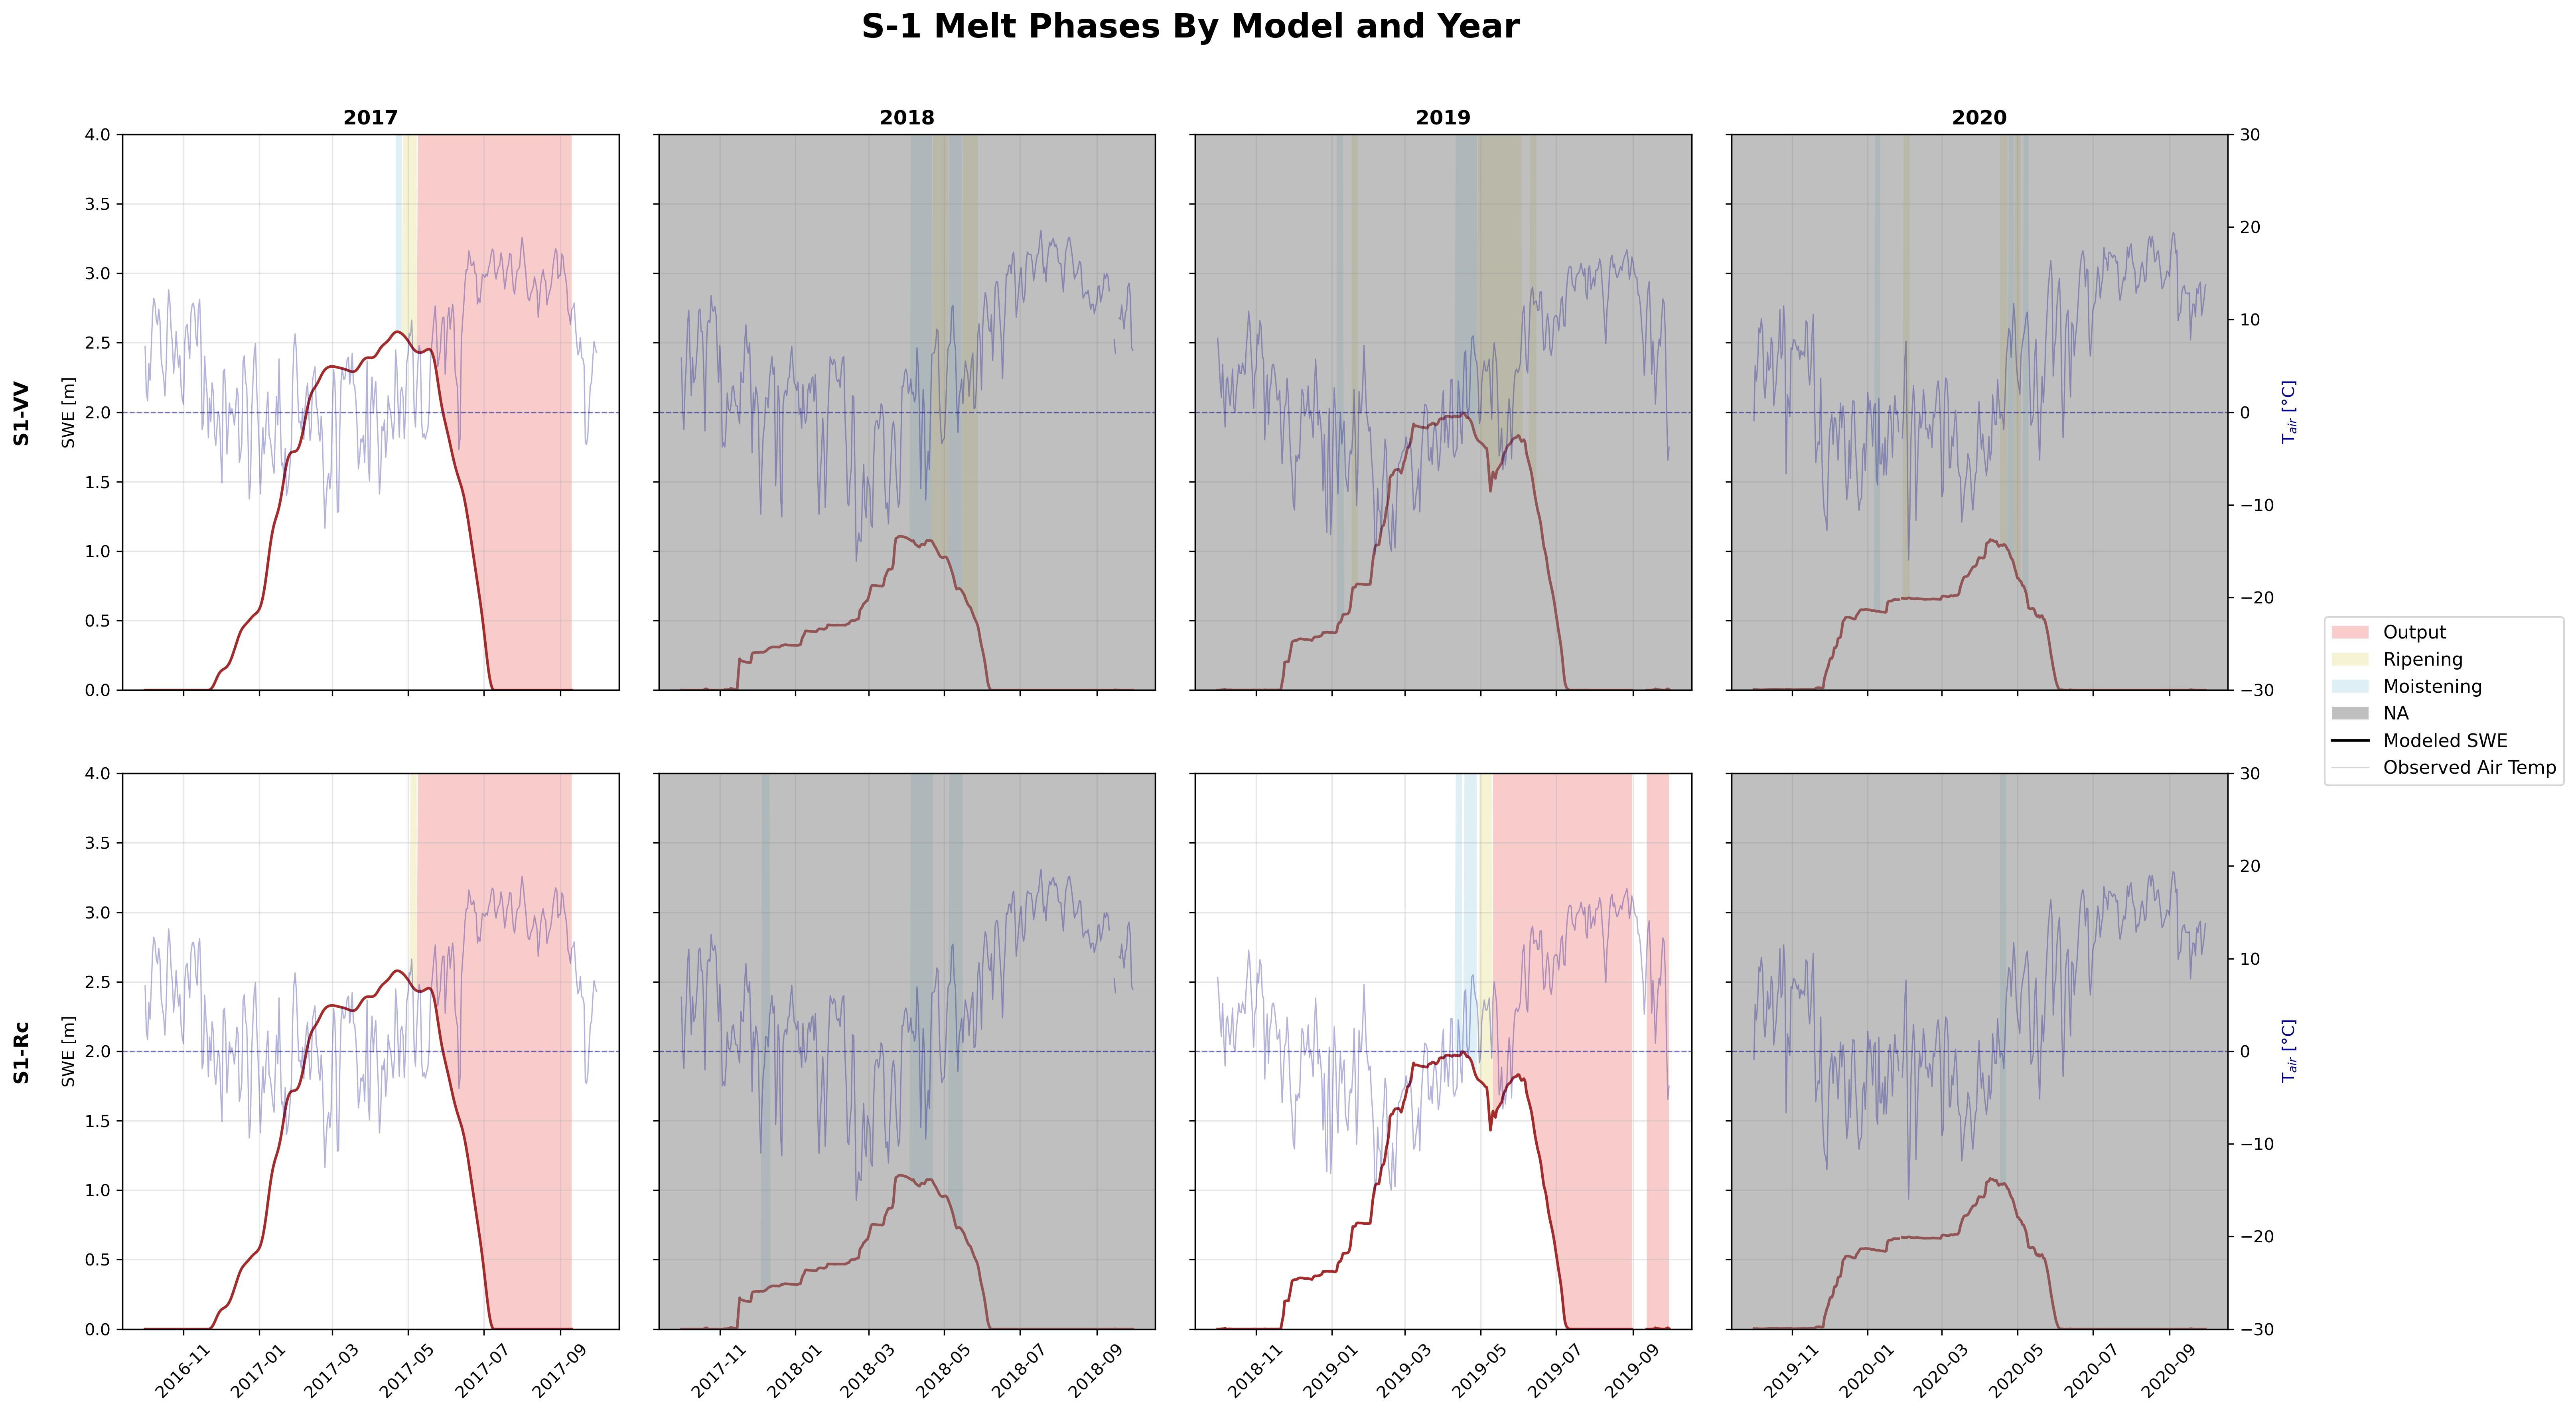

In [18]:
importlib.reload(plotting)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(2, 4, figsize=(20, 12), dpi=300, sharex='col',sharey = True)
row_labels = ["S1-VV", "S1-Rc"]
col_years = [2017, 2018, 2019, 2020]
# ylims = [4, 1.5, 3, 1.2]
ylims = [4, 4, 4, 4]

for i in range(2):
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2017[i], phase_s1_data_2017[i], ax=axes[i][0], ylim_=ylims[0], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2018[i], phase_s1_data_2018[i], ax=axes[i][1], ylim_=ylims[1], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2019[i], phase_s1_data_2019[i], ax=axes[i][2], ylim_=ylims[2], title="")
    leg,_ = plotting.plot_melt_phases_intervals_filltop(swe_obs_data_2020[i], phase_s1_data_2020[i], ax=axes[i][3], ylim_=ylims[3], title="")

# Plot air temperature on secondary y-axis and add gray 0°C line
for j in range(4):
    wy = col_years[j]
    df_slice = ds_temp_day.where(ds_temp_day['datetime'] >= np.datetime64(f'{wy-1}-10-01'), drop=True) \
                          .where(ds_temp_day['datetime'] < np.datetime64(f'{wy}-10-01'), drop=True).to_dataframe().reset_index()
    
    for i in range(2):
        ax2 = axes[i][j].twinx()
        # Plot air temperature if available
        if not df_slice.empty:
            ax2.plot(df_slice['datetime'], df_slice['air_temperature'], color='darkblue', alpha=0.3, linewidth=0.75)
        # Always plot 0°C reference line in gray
        ax2.axhline(0, color='darkblue', linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
        ax2.set_ylim(-30, 30)
        if j == 3:
            ax2.set_ylabel("T$_{air}$ [°C]", color='darkblue')
        else:
            ax2.set_yticklabels([])
            ax2.tick_params(right=False)

for j, yr in enumerate(col_years):
    axes[0][j].set_title(str(yr), fontweight='bold')

# First column: SWE label + row label on the right side
for i, lbl in enumerate(row_labels):
    axes[i][0].set_ylabel("SWE [m]")
    axes[i][0].annotate(lbl, xy=(0, 0.5), xytext=(-55, 0),
                        xycoords='axes fraction', textcoords='offset points',
                        ha='right', va='center', fontweight='bold', fontsize=12,
                        rotation=90)

# Remove y-axis labels for non-first-column subplots
for i in range(2):
    for j in range(1, 4):
        axes[i][j].set_ylabel("")
        axes[i][j].tick_params(labelleft=False)

# Rotate x-tick labels in the last row
for j in range(4):
    axes[-1][j].tick_params(axis='x', rotation=45)


gray_out = [(0, 1),(0,2),(0,3),(1,1),(1,3)]  # (row, col) pairs to gray out — add more as needed
for r, c in gray_out:
    axes[r][c].add_patch(Rectangle((0, 0), 1, 1, transform=axes[r][c].transAxes,
                                   facecolor='gray', alpha=0.5, zorder=100))

# Add SWE and T_air line handles to the legend
leg["NA"] = Patch(facecolor='gray', alpha=0.5)
leg["Modeled SWE"] = Line2D([0], [0], color='black', linewidth=1.6)
leg["Observed Air Temp"] = Line2D([0], [0], color='gray', alpha=0.3, linewidth=0.75)

plt.suptitle("S-1 Melt Phases By Model and Year", fontweight='bold', fontsize=20)
fig.tight_layout(rect=[0, 0, 0.97, 0.96])
fig.subplots_adjust(hspace=0.15, wspace=0.08)

fig.legend(leg.values(), leg.keys(), loc='center left', bbox_to_anchor=(0.97, 0.5),
           fontsize=11, frameon=True)

### S1 QC Summary Comparison

In [19]:

import pandas as pd

YEARS = [2017, 2018, 2019, 2020]
ORBITS = ["64", "137", "144"]

vv_outs      = {2017: vv_out_2017,       2018: vv_out_2018,       2019: vv_out_2019,       2020: vv_out_2020}
weighted_outs = {2017: weighted_out_2017, 2018: weighted_out_2018, 2019: weighted_out_2019, 2020: weighted_out_2020}

rows = []
for yr in YEARS:
    vv_diag  = vv_outs[yr].get("diagnostics", {})
    wt_diag  = weighted_outs[yr].get("diagnostics", {})
    vv_per   = vv_diag.get("per_orbit", {})
    wt_per   = wt_diag.get("per_orbit", {})

    for o in ORBITS:
        vv_orb = vv_per.get(o, {})
        wt_orb = wt_per.get(o, {})
        rows.append({
            "Year":           yr,
            "Orbit":          o,
            "VV orbit ok":    "✓" if vv_orb.get("ok") else "✗",
            "VV orbit reason": vv_orb.get("reason", "—"),
            "Wt orbit ok":    "✓" if wt_orb.get("ok") else "✗",
            "Wt orbit reason": wt_orb.get("reason", "—"),
        })

    # Overall (group-level) row
    rows.append({
        "Year":           yr,
        "Orbit":          "OVERALL",
        "VV orbit ok":    "✓" if vv_outs[yr].get("qc_ok") else "✗",
        "VV orbit reason": vv_outs[yr].get("qc_reason", "—"),
        "Wt orbit ok":    "✓" if weighted_outs[yr].get("qc_ok") else "✗",
        "Wt orbit reason": weighted_outs[yr].get("qc_reason", "—"),
    })

df_qc = pd.DataFrame(rows).set_index(["Year", "Orbit"])

# Style: highlight OVERALL rows and failures
def style_row(row):
    is_overall = row.name[1] == "OVERALL"
    styles = []
    for col in row.index:
        if is_overall:
            styles.append("font-weight: bold; background-color: #f0f0f0")
        elif "✗" in str(row[col]):
            styles.append("color: #c0392b")
        else:
            styles.append("")
    return styles

df_qc.style.apply(style_row, axis=1)


### S1 QC Examples

#### S1-VV 2017 - BAD_REFERENCE_OR_NO_CONTRAST

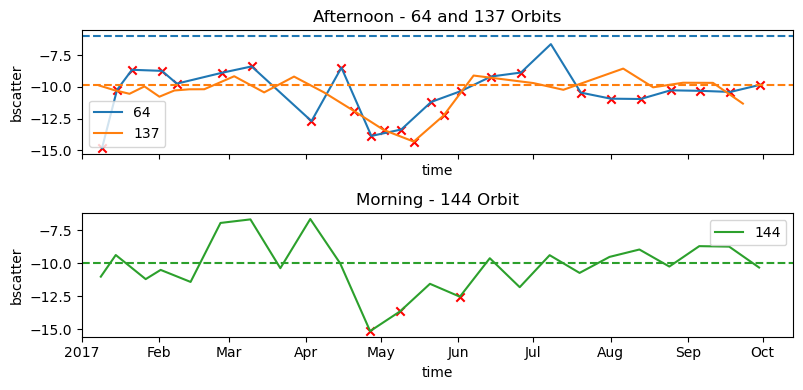

In [20]:
importlib.reload(melt_phases)
# 1) build point timeseries per orbit from files
__ = melt_phases.s1_bsc_ref(sentinel_cues_100m_2017,
                       sentinel_cues_reference_2017,
                       idy_ = idy_cues,
                       idx_ = idx_cues,
                       showPlot = True,
                       figsize = (8,4),
                       savePlot = True,
                       figname = 'S2_JDSSS_S1_FailQC_EX_1',
                           )

#### S1-VV 2018 - NOISY_SIGNAL

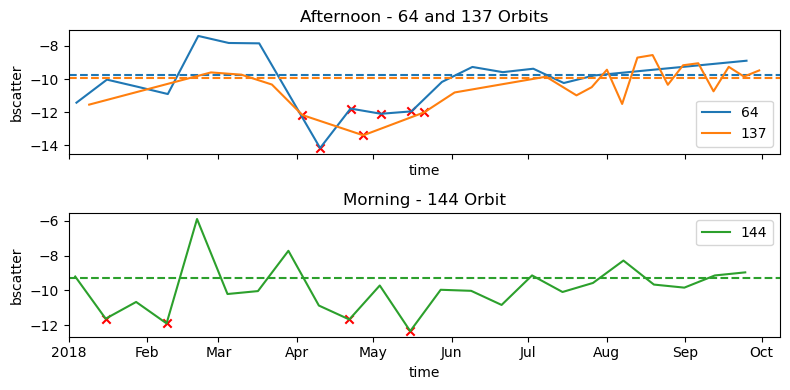

In [21]:
importlib.reload(melt_phases)
# 1) build point timeseries per orbit from files
__ = melt_phases.s1_bsc_ref(sentinel_cues_100m_2018,
                       sentinel_cues_reference_2018,
                       idy_ = idy_cues,
                       idx_ = idx_cues,
                       showPlot = True,
                       figsize = (8,4),
                       savePlot = True,
                       figname = 'S3_JDSSS_S1_FailQC_EX_2',
                           )

#### S1-VV 2019 - AM_PM_MINIMA_MISMATCH

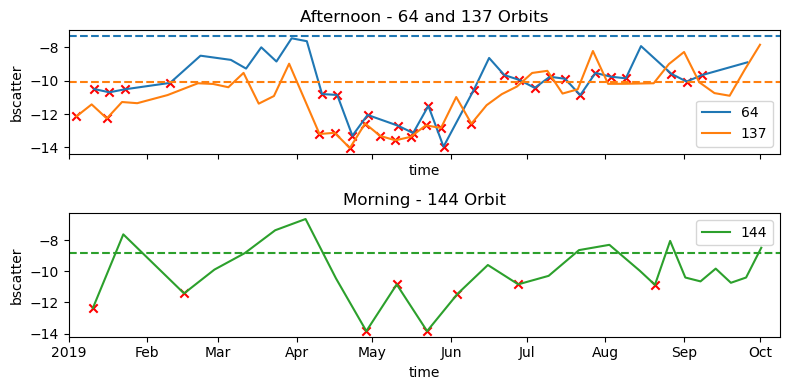

In [22]:
importlib.reload(melt_phases)
# 1) build point timeseries per orbit from files
__ = melt_phases.s1_bsc_ref(sentinel_cues_100m_2019,
                       sentinel_cues_reference_2019,
                       idy_ = idy_cues,
                       idx_ = idx_cues,
                       showPlot = True,
                       figsize = (8,4),
                       savePlot = True,
                       figname = 'S4_JDSSS_S1_FailQC_EX_3',
                           )